# LGBM & XGBM

### Objective:

In [1]:
## ● The objective of this assignment is to compare the performance of Light GBM and XG Boost algorithms using the Titanic dataset. 

### Exploratory Data Analysis (EDA):

In [2]:
## ● 1.	Load the Titanic dataset using Python's pandas library.
## ● 2.	Check for missing values.
## ● 3.	Explore data distributions using histograms and box plots.
## ● 4.	Visualize relationships between features and survival using scatter plots and bar plots.

In [3]:
## importing required libraries..
import pandas as pd
import numpy as np

In [4]:
## Since the dataset ('Titanic_train' and 'Titanic_test') that we are going to use in this assignment, we have aready dealt with this dataset in assignment 7 (logistic regression)..
## We already know few things about this dataset..
## The target column 'Survived' in the 'Titanic_test' dataset is missing so we are not going to use that dataset.. 
## We will only use Titanic_train dataset to train and evaluate the model by dividing the train dataset itself into training and testing dataset using train test split method..

In [5]:
## Loading and diplaying the training dataset..
df_train = pd.read_csv("Titanic_train.csv")
df_train.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [6]:
## Loading the testing dataset
df_test = pd.read_csv("Titanic_test.csv")
df_test.head(2)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S


In [7]:
print(df_train.columns)
print(df_test.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [8]:
## We can see that the testing dataset that we have been provided with doesn't have 'Survived' column, which is also the target variable..
## That means by using the testing dataset we wont't be able to evaluate the model.. 
## So we will be using the training dataset only to build and evaluate the model by splitting the dataset into training and testing dataset..

In [9]:
## Top 3 records..
## This dataset contains information about passengers aboard the Titanic..
df_train.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [10]:
df_train.info()

## Total 12 columns and 891 records.. we have combination of both numerical and categorical columns..
## Target column is 'Survived'.. categorical target.. in the form of 0, 1.. 0--> Not survived, 1--> Survived..
## Few null values can be seen.. 
## 2 missing values in 'Embarked'..177 missing values in 'Age' 
## 687 missing values in Cabin (too much).. we probably have to drop it down later..

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
df_train.describe()

## The average passenger Age is 29.7 years with values ranging from 0.42 to 80 years..
## The average fair paid is around 32.2, with a maximum value of 512 indicating the presence of outliers..
## The mean survival rate is 0.38, meaning around 38% of the passengers survived..
## Most passengers have 0 sibling/spouses (SibSp) and 0 psarents/children (Parch) means many passengers were travelling alone..

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
df_train["Survived"].value_counts()

## The target variable is kind of imbalanced with fewer survivors compared to non survivors.. 

Survived
0    549
1    342
Name: count, dtype: int64

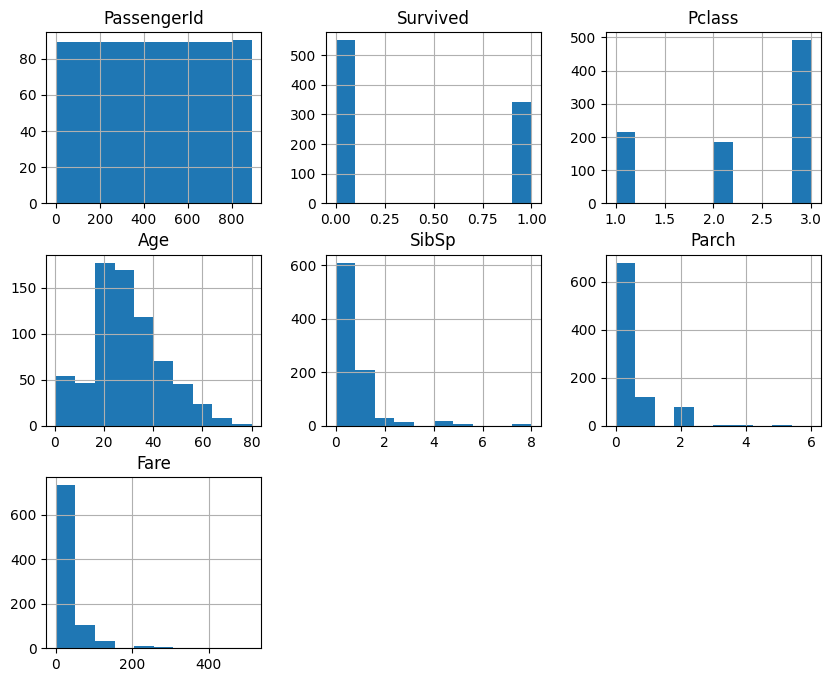

In [13]:
## Visualization..
## Histogram..
import matplotlib.pyplot as plt
df_train.hist(figsize = (10,8))
plt.show()

## Survived (Target variable) clearly imbalanced.. more 0 (not survived) that 1 (survived)..
## Pclass.. most passengers in class 3.. this will most likely influence the survival..
## Age column roughly looks normally distributed but slightly skewed..
## SibSp & Parch .. highly skewed column.. most values are around 0 .. few travelled with family only.. 
## Fare column.. It his highly skewed.. we can see extreme high values (outliers).. 
## PssengerID .. it has no use for buildiong model so we will be dropping it going forward.. 

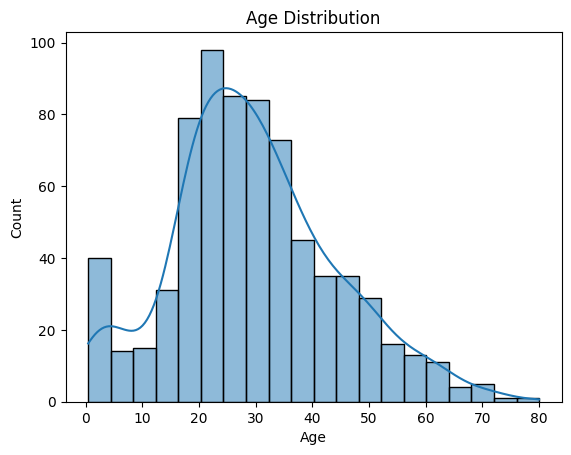

In [14]:
## Age distribution..
import seaborn as sns
sns.histplot(df_train["Age"],kde = True)
plt.title('Age Distribution')
plt.show()

## The age distribution shows that most passengers were between 20-40 years old..
## The distribution is slightly right skewed and missing values are present in this feature..

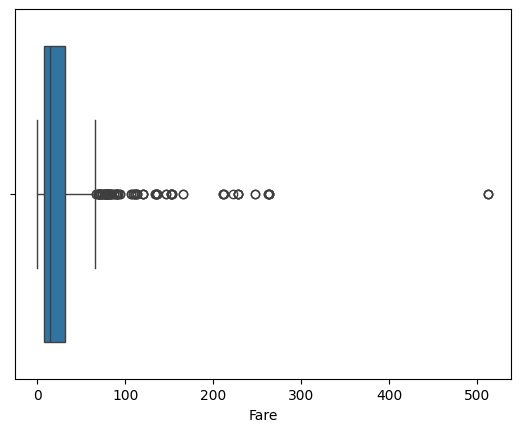

In [15]:
## Fare distribution..
sns.boxplot(x = df_train["Fare"])
plt.show('Fare Distribution')
plt.show()

## The boxplot of fare shows the presence of several high value outliers
## Indicating that a few passenger paid significantly higher fares compared to majority, also beacuse mean is near lower whisker..

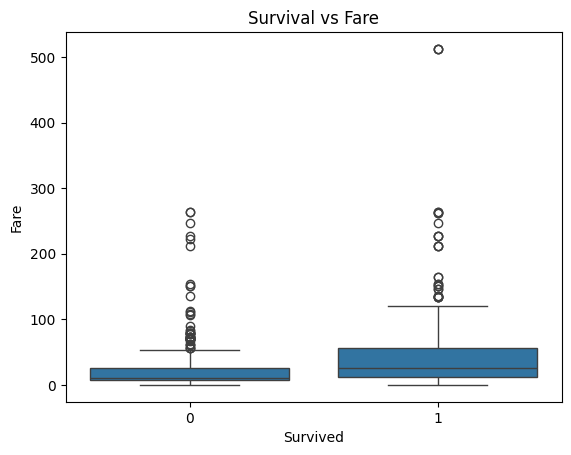

Survived
0    10.5
1    26.0
Name: Fare, dtype: float64


In [16]:
## Survival vs Fare..
sns.boxplot(x = "Survived", y = "Fare", data = df_train)
plt.title('Survival vs Fare')
plt.show()

print(df_train.groupby("Survived")["Fare"].median())

## Passengers who survived tend to have paid higher fares on average suggesting that wealthier passengers had better chances of survival..
## Median fare of survivors (26) is higher than that of non survivors (10.5)..

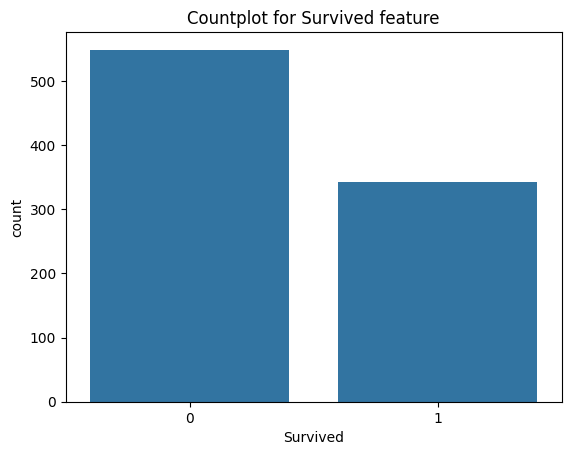

Survived
0    549
1    342
Name: count, dtype: int64


In [17]:
sns.countplot(x = "Survived", data = df_train)
plt.title('Countplot for Survived feature')
plt.show()

print(df_train["Survived"].value_counts())

## The count plot of the target variable shows that the number of passenger who did not survive (549) is higher than those who survived (342)..
## This indicates a slight class imbalance in the dataset..

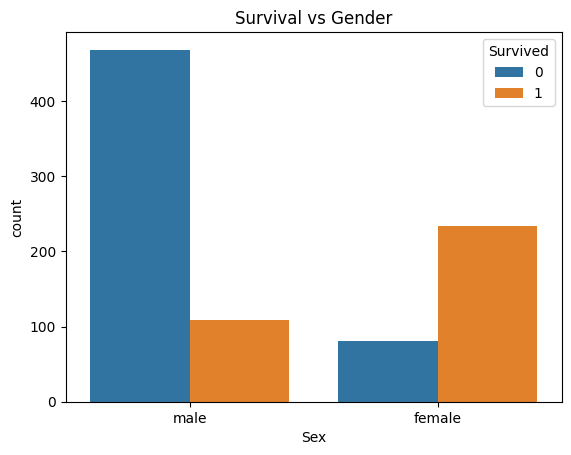

Total survivors by gender
Sex
female    233
male      109
Name: Survived, dtype: int64
****************************************************************************************************
Value Count of Sex
Sex
male      577
female    314
Name: count, dtype: int64


In [18]:
## Survival vs Gender 
sns.countplot(x = "Sex", hue = "Survived", data = df_train)
plt.title('Survival vs Gender')
plt.show()

print("Total survivors by gender")
print(df_train.groupby("Sex")["Survived"].sum()) # Total survivors by gender..
print("*"*100)
print("Value Count of Sex")
print(df_train["Sex"].value_counts())
## The visualisation shows that a significantly higher proportion of females survived (74%) compared to males (18%)..
## Most male passengers did not survive, indicating that gender played a crucial role in survival..

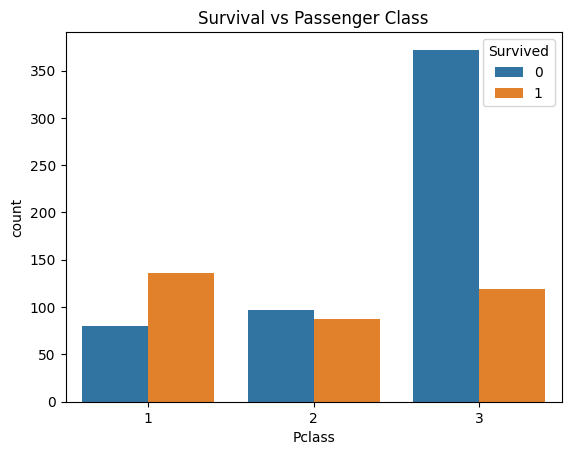

Total survivors by pcalss
Pclass
1    136
2     87
3    119
Name: Survived, dtype: int64
****************************************************************************************************
Value Count of pclass
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [19]:
## Survival vs Passenger class
sns.countplot(x = "Pclass", hue = "Survived", data = df_train)
plt.title('Survival vs Passenger Class')
plt.show()

print("Total survivors by pcalss")
print(df_train.groupby("Pclass")["Survived"].sum())
print("*"*100)

print("Value Count of pclass")
print(df_train["Pclass"].value_counts())
## Passenger in Pclass = 1 had a higher survival rate (62.96%) compared to those in middle (47%) and lower class (24%)..
## Most passengers in Pclass = 3 did not survive, it suggests that somehow socio-economic status influenced survival chance..
## The highest number of survivors is in Pclass = 1 (136), followed by Pclass 3 (119) then Pclass 2 (87).. 

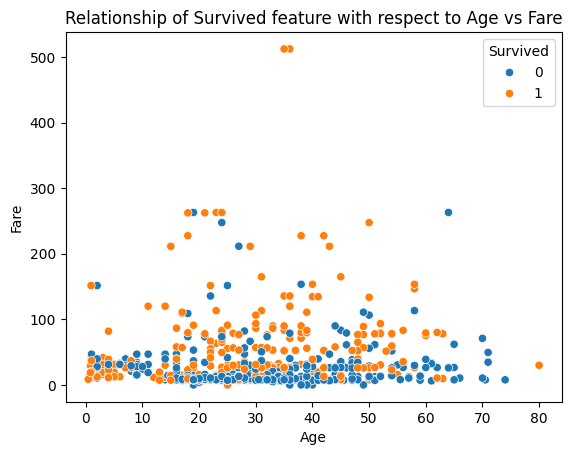

In [20]:
## Age vs Fare..  Survival..
sns.scatterplot(x = "Age", y = "Fare", hue = 'Survived', data = df_train)
plt.title('Relationship of Survived feature with respect to Age vs Fare')
plt.show()

## Most passengers paid low fares (0-100) irrespective of age..
## There is no strong linear relationship between Age and Fare..
## However orange points(survived) are more frequent at higher fare values.. means those who paid more had better survival chance.. 
## Some extreme fare value can be seen (>500).. 
## Hence fare is an important feature for survival prediction.. meanwhile Age alone does not strongly determine survival.. 

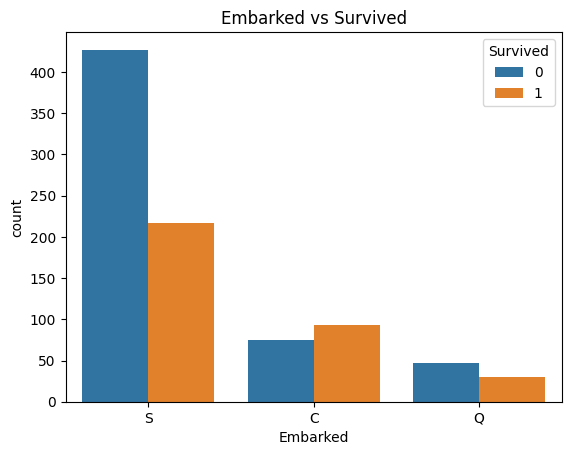

Total survivors by Embarked
Embarked
C     93
Q     30
S    217
Name: Survived, dtype: int64
****************************************************************************************************
Value Count of Embarked
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [21]:
## Embarked vs Survived 
sns.countplot(x = "Embarked", hue = "Survived", data = df_train)
plt.title('Embarked vs Survived')
plt.show()

print("Total survivors by Embarked")
print(df_train.groupby("Embarked")["Survived"].sum())
print("*"*100)

print("Value Count of Embarked")
print(df_train["Embarked"].value_counts())
## Most of the passenger boarded from 'S' (southhampton)..
## If we talk about survival rate, C (Cherbourg) has higher proportion of survivors.. 'S' has lower survival rate.. 
## 'Q' (queenstown) slightly lower survial rate compared to 'C'.. 
## So we can say that there is an relationship of target variable with Embarked feature.. 
## Maybe it reflects class distribution or socio-economic status..

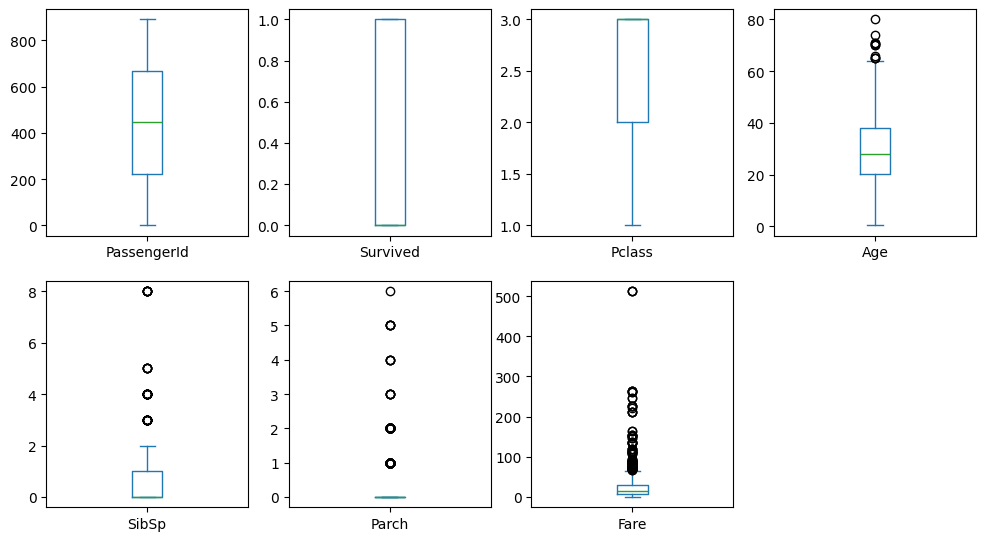

In [22]:
## Boxplot.. 

df_train.plot(kind = 'box', subplots = True, layout = (3,4), figsize = (12, 10))
plt.show()

## As we know PassengerId can be ignored because it has no use in model building..
## Survived, target variable and  a binary columns.. we already it is imbalanced which will be dealt with later in next step..
## Pclass (1,2,3).. its has slight ordinal charater (class).. most of the people are in class 3..
## Age.. median is around 28-30.. spread is wide.. some outliers above 60..
## SibSp (sibiling, spouse).. most values are around 0.. few high outliers.. most of the passengers travelled alone.. 
## Parch (Parents-children).. it is similar to SibSp.. mostly 0.. few families were there only..
## Fare.. Many outliers can be seen at the higher end (high fare).. it suggets right skewness in distribution..   

In [23]:
## select numerical columns only 
num_cols = df_train.select_dtypes(include = ['int64', 'float64']).columns
num_cols

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [24]:
## IQR and related statistics to outliers.. 
for i in num_cols:
    Q1 = df_train[i].quantile(0.25)
    Q3 = df_train[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    min_val = df_train[i].min()
    max_val = df_train[i].max()

    ## detect outliers..
    outliers = df_train[(df_train[i] < lower_bound) | (df_train[i] > upper_bound)][i]

    print(f"\nColumn: {i}")
    print(f"Q1 : {Q1}")
    print(f"Q3 : {Q3}")
    print(f"IQR : {IQR}")
    print(f"Lower Bound : {lower_bound}")
    print(f"Upper Bound : {upper_bound}")
    print(f"Minimum Value : {min_val}")
    print(f"Maximum Value : {max_val}")
    print(f"Potential Outiers : {len(outliers)}")
##    if len(outliers) > 0:
##        print("Potential Outliers:")
##        print(outliers.values)
    
##    plt.figure(figsize = (7, 2))
##    plt.boxplot(df_train[i].dropna(), vert = False)
##    plt.title(f"Boxplot of {i}")
##    plt.show()
    print("*"*100)


Column: PassengerId
Q1 : 223.5
Q3 : 668.5
IQR : 445.0
Lower Bound : -444.0
Upper Bound : 1336.0
Minimum Value : 1
Maximum Value : 891
Potential Outiers : 0
****************************************************************************************************

Column: Survived
Q1 : 0.0
Q3 : 1.0
IQR : 1.0
Lower Bound : -1.5
Upper Bound : 2.5
Minimum Value : 0
Maximum Value : 1
Potential Outiers : 0
****************************************************************************************************

Column: Pclass
Q1 : 2.0
Q3 : 3.0
IQR : 1.0
Lower Bound : 0.5
Upper Bound : 4.5
Minimum Value : 1
Maximum Value : 3
Potential Outiers : 0
****************************************************************************************************

Column: Age
Q1 : 20.125
Q3 : 38.0
IQR : 17.875
Lower Bound : -6.6875
Upper Bound : 64.8125
Minimum Value : 0.42
Maximum Value : 80.0
Potential Outiers : 11
****************************************************************************************************

Co

In [25]:
## Conclusion..
## Dataset contain missing values in Age, Cabin and Embarked..
## Fare and PClass strongly influence survival.. Embarked location impact survival probability as well..
## Features like PassengerID and Name are not useful, will be removed.. 
## Numerical feature like Fare are skewed with outliers.. mosr passengers travelled alone (SibSp, Parch) and paid lower fare..
## No strong relationship between Age and Fare but survival increases with Fare.. 

### Data Preprocessing

In [26]:
## ● 1.	Impute missing values.
## ● 2.	Encode categorical variables using one-hot encoding or label encoding.
## ● 3.	If needed you can apply more preprocessing methods on the given dataset.

In [27]:
print(df_train.isnull().sum())
print(df_train.shape)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
(891, 12)


In [28]:
## Lets fill Age with median(won't get affected by outliers)..
df_train['Age'].fillna(df_train['Age'].median(), inplace = True)


## df_train['Age'] = df_train['Age'].fillna(df_train['Age'].median(), inplace = True)

C:\Users\devlok\AppData\Local\Temp\ipykernel_1788\75304043.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['Age'].fillna(df_train['Age'].median(), inplace = True)


In [29]:
## lets fill Embarked with mode.. 
df_train['Embarked'].fillna(df_train['Embarked'].mode()[0], inplace = True)

C:\Users\devlok\AppData\Local\Temp\ipykernel_1788\2622597507.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['Embarked'].fillna(df_train['Embarked'].mode()[0], inplace = True)


In [30]:
## lets drop cabin because there are too many missing values.. 
df_train.drop(columns = ['Cabin'], inplace= True)

In [31]:
print(df_train.isnull().sum())
## Mising values in Age and Embarked are successfully dealt with..
## and cabin column is also successfully removed 

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [32]:
## Lets drop the rest of the useless columns (columns that won't be contributing to the model for prediction).. 
df_train.drop(columns = ['PassengerId', 'Name', 'Ticket'], inplace = True)
df_train.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

In [33]:
df_train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [34]:
## Now encoding part of categorical columns.. 
## We have to deal with Sex, Embarked.. 
df_train = pd.get_dummies(df_train, columns = ['Sex', 'Embarked'], drop_first = True)
## Drop _first (helps to avoid multicollinearity )

In [35]:
df_train.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [36]:
## last step before splitting the data in training and testing data is Define X and Y 
X = df_train.drop('Survived',axis = 1)
Y = df_train['Survived']

### Building Predictive Models

In [37]:
## ● 1.	Split the preprocessed dataset into training and testing sets.
## ● 2.	Choose appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score) for model evaluation.
## ● 3.	Build predictive models using LightGBM and XGBoost algorithms.
## ● 4.	Train the models on the training set and evaluate their performance on the testing set.
## ● 5.	Use techniques like cross-validation and hyperparameter tuning to optimize model performance.

In [38]:
## lets split the data..

In [39]:
from  sklearn.model_selection import train_test_split

In [40]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42, stratify = Y)

## stratify = y.. it helps keep the imbalance class consistent in both train and test set.. 

In [41]:
## We dont neccessarily need scaling because tree models do not need it..
## Data is successfulyy cleaned and ready for training the model.. 

### XGBoost

In [42]:
## Lets build XGBoost first..
from xgboost import XGBClassifier

In [43]:
## baseline model.. 
xgb = XGBClassifier( random_state = 42)
xgb.fit(X_train, Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [44]:
## prediction..
Y_pred_xgb = xgb.predict(X_test)

In [45]:
## evaluation.. 
from sklearn.metrics import classification_report , accuracy_score

In [46]:
print('Accuracy:', accuracy_score(Y_test, Y_pred_xgb))
print(classification_report(Y_test, Y_pred_xgb))

Accuracy: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       110
           1       0.76      0.72      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [47]:
## Model tuning 
## n_estimators = 200 (more trees better learning), max_depth = 4 (help to avoid overfitting)..
## learning_rate = 0.5 (slower the learning rate better generalization).. subsample and  colsample_bytree helps reduce overfitting.. 
xgb_tuned = XGBClassifier(n_estimators = 200, max_depth = 4, learning_rate = 0.05, subsample = 0.8, colsample_bytree = 0.8, random_state = 42)
xgb_tuned.fit(X_train, Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [48]:
## prediction for tuned..
Y_pred_xgb_tuned = xgb_tuned.predict(X_test)

In [49]:
## evaluation for tuned
print('Tuned Accuracy:', accuracy_score(Y_test, Y_pred_xgb_tuned))
print(classification_report(Y_test, Y_pred_xgb_tuned))

Tuned Accuracy: 0.7932960893854749
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       110
           1       0.78      0.65      0.71        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179



In [50]:
## Interpretation 
## Baseline model achieved an accuracy of approximately 80% indicating good overall predective performance..
## For the majority class (not survived), the model performed well with high precision and recall..
## For minority class (survived), the model achieved a recall around 0.72, showing a reasonable ability to correctly identify survivors..
## Though some cases were still missed..

## A tuned version of the XGBoost model was also developed by adjusting hyperparameter such as the number of estimators, maximum depth, leasrning rate and samplimg parameters.. 
## However the tuned model resulted in a slight decrease in performance, with accuracy dropping around 79% ..
## And recall for the survived class also decreased further ..
## This suggest that tuning introduced more regularization, which led to underfitting on this relatively small dataset..

## Overall the baseline XGBoost model performed better than the tuned version..
## This indicates that the default configuration was already well suited for he dataset..
## This highlights that hyperparameter tuning does not always guarantee improved performance..
## Especially when working with smaller datasets.. 
## Therefore the baseline  XGBoost model was selected as the final model for comparision with other algorithms.. 

### LightGBM

In [51]:
## Import library.. 
from lightgbm import LGBMClassifier

In [52]:
## Baseline model.. 
lgbm = LGBMClassifier(random_state = 42)

lgbm.fit(X_train, Y_train)

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000340 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 206
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [53]:
## Model is built successfully.. 
## But i got some warnings..
## I got these warning most probably because dataset is very small, hence limited patterns,  not many strong splits available..
## There are only few features available, remaining features are limited..
## LightGBM is a powerfull model, Titanic seems to be very simple dataset comparitivly.. so it ran out of useful splits quickly..  

In [54]:
## prediction..
Y_pred_lgbm = lgbm.predict(X_test)

In [55]:
## evaluation baseline..
print('Accuracy:', accuracy_score(Y_test, Y_pred_lgbm))
print(classification_report(Y_test, Y_pred_lgbm))

Accuracy: 0.7988826815642458
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       110
           1       0.75      0.71      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [56]:
## Now lets tune it..
## We will use same tuning parameters as XGBoost..
lgbm_tuned = LGBMClassifier(n_estimators = 200, max_depth = 4, learning_rate = 0.05, subsample = 0.8, colsample_bytree = 0.8, random_state = 42)
lgbm_tuned.fit(X_train, Y_train)

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000488 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 206
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,4
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [57]:
## Model is successfully built, got the same warning as discussed above.. 

In [58]:
## Prediction tuned.. 
Y_pred_lgbm_tuned = lgbm_tuned.predict(X_test)

In [59]:
## Evaluation for tuned model..
print('Tuned Accuracy:', accuracy_score(Y_test, Y_pred_lgbm_tuned))
print(classification_report(Y_test, Y_pred_lgbm_tuned))

Tuned Accuracy: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [60]:
## Accuracy remained almost same, no real improvement after tuning.. 
## Recall for survival decereased, model is missing more actual survival after tuning..
## Class 0 (not survived) performance increased a bit.. but at the cost of class 1.. 
## Same thing happened as XGBoost.. tuning made model more conservative..slight bias toward majority class (not surviced)..
## No real benifit..
## Again the reasons are same.. dataset is quite small with less features.. 
## So in LightBGM also we are going to choose baseline model as final model for comparision with XGBoost baseline model.. 

In [61]:
## Both XGBoost and LightBGM achieved similar accuracy of around 80% on the titanic dataset on their respective base model..
## However XGBoost performed slightly better in identifying the survived class, showing higher recall..
## Hyperparameter tuning did not imporove performance of either model and slightly reduced recall..
## Overall XGBoost performed slightly better than LightGBM, but the difference is minimal due to the small dataset..

### Comparative Analysis:

In [62]:
## ● 1.	Compare the performance metrics (e.g., accuracy, precision, recall) of LightGBM and XGBoost models.
## ● 2.	Visualize and interpret the results to identify the strengths and weaknesses of each algorithm.

In [63]:
## comparitive analysis 

## comparision of performance metrics..
## Both XGBoost and LightBGM models were evaluated using accuracy, precision, recall and F1-score..
## The accuracy of both the model is around 80% indicatiing similar overall performace ..
## In terms of precision both models performed almost equally well for both classes..
## For recall XGBoost showed slightly better performence for the survived clas compared to LightBGM.. means it is better at identifying actual survivors..
## The F1-score which balances precision and recall is also slightly better for XGBoost for the minority class (survived)..
## Overall both models performed similarly but XGBoost is slightly better in handelling the minority class..

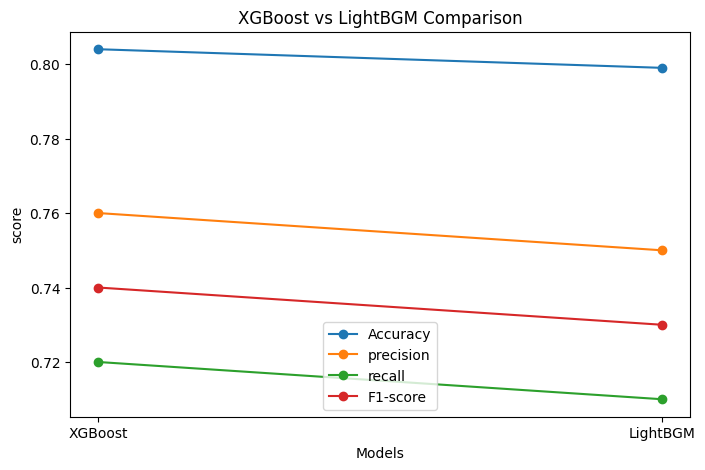

In [64]:
models = ['XGBoost', 'LightBGM']

accuracy = [0.804, 0.799]
precision = [0.76, 0.75]
recall = [0.72, 0.71]
f1_score = [0.74, 0.73]

plt.figure(figsize = (8, 5))

plt.plot(models, accuracy, marker = 'o', label = 'Accuracy')
plt.plot(models, precision, marker = 'o', label = 'precision')
plt.plot(models, recall, marker = 'o', label = 'recall')
plt.plot(models, f1_score, marker = 'o', label = 'F1-score')

plt.xlabel('Models')
plt.ylabel('score')
plt.title('XGBoost vs LightBGM Comparison')
plt.legend()

plt.show()

In [65]:
## From the above plot it is clear that both models shows similar accuracy indicating no major difference ..
## XGBoost perfors slightly better in recall for the Survived category.. which makes it more suitable because identifying surivors is important..
## LightBGM is slightly more biased toward the majority class (non survivors), which leads to lower recall for survivors..
## As we saw above hyperparameter tuning did not significantly improve performance and slightly reduced recall in both tuned models, that why we chose baseline models as final models for comparisions..

## In short XGBoost better for handling the minority class..
## LightBGM is fast and efficient and similar overall accuracy..
## Both struggles a bit due to class imbalance and smaller dataset.. 

In [66]:
## FINAL CONCLUSION and REPORT

## In this assignment both XGBoost and LightBGM models were applied to the Titanic dataset to predict the passenger survival chances..
## After preprocessing and model evaluation both models achieved similar performance with an accuracy of around 80%..
## However XGBoost performed slightly better in terms of recall for the survival class (minority class) which made it lot more effective in identifying actual surviors..

## Hyperparameter tuning did not significantly improve the performance pf either of the models and in some cases led to slight decrease ..
## This indcated that baseline models were already better with this relatively small dataset (Titanic).. 
## Also the presence of class imbalance affected the model's ability to perfectly predict the survival class.. 

## Overall both the basline models performed well but XGBoost showed slight advantage..
## The classification report showedus that model performance depends not only on the algorithm but also on dataset size, feature quality and class distribution.. 